In [7]:
import csv
import json

In [30]:
import csv

file_path = 'weather_data/sitka_weather_2021_simple.csv'

with open(file_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    
    # 헤더 출력
    print('header:', reader.fieldnames)
    result = []
    
    # 첫 줄만 출력
    for line in reader:
        try:
            row = {
                line['STATION'],
                line['NAME'],
                line['DATE'],
                float(line['TMAX']) if line['TMAX'] else None,
                float(line['TMIN']) if line['TMIN'] else None
            }
            result.append(row)
            print(row)
            break  # 첫 줄만 보고 싶을 경우
        except ValueError as e:
            print("데이터 변환 오류:", e)
            continue

print("결과 리스트:", result)



header: ['STATION', 'NAME', 'DATE', 'TAVG', 'TMAX', 'TMIN']
{'USW00025333', 40.0, 44.0, '2021-01-01', 'SITKA AIRPORT, AK US'}
결과 리스트: [{'USW00025333', 40.0, 44.0, '2021-01-01', 'SITKA AIRPORT, AK US'}]


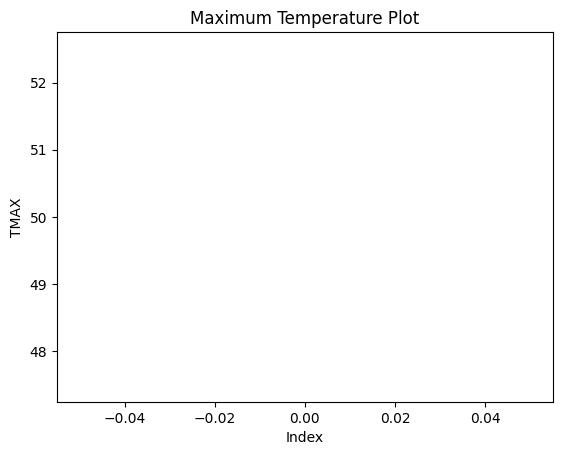

In [36]:
import matplotlib.pyplot as plt

result = []

# 예: result에 데이터를 넣을 때도 list로 유지
result.append(["STATION", "NAME", "DATE", 50.0, "TMIN"])

x = range(len(result))
y = [r[3] for r in result]  # TMAX 데이터
plt.plot(x,y)
plt.xlabel('Index')
plt.ylabel('TMAX')
plt.title('Maximum Temperature Plot')
plt.show()

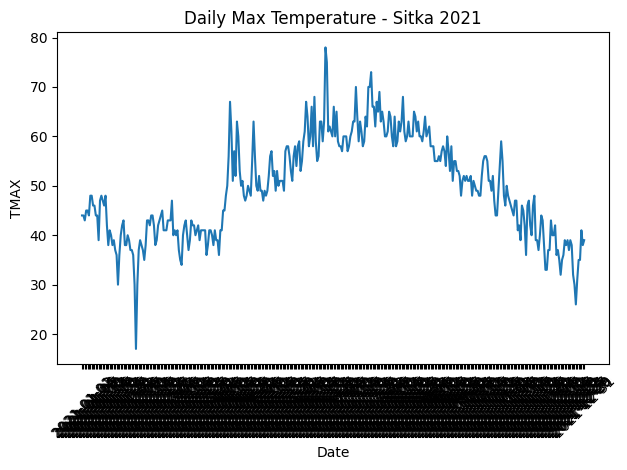

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('weather_data/sitka_weather_2021_simple.csv')
df['TMAX'] = pd.to_numeric(df['TMAX'], errors='coerce')  # 결측값 NaN 처리
plt.plot(df['DATE'], df['TMAX'])
plt.xticks(rotation=45)
plt.title('Daily Max Temperature - Sitka 2021')
plt.xlabel('Date')
plt.ylabel('TMAX')
plt.tight_layout()
plt.show()


In [16]:
result[0]

{'2021-01-01', 40.0, 44.0, 'SITKA AIRPORT, AK US', 'USW00025333'}

In [18]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [26]:
import pandas as pd

file_path = 'weather_data/sitka_weather_2021_simple.csv'
df = pd.read_csv(file_path)
df.head()

,STATION,NAME,DATE,TAVG,TMAX,TMIN
0,USW00025333,"SITKA AIRPORT, AK US",2021-01-01,NaN,44,40
1,USW00025333,"SITKA AIRPORT, AK US",2021-01-02,NaN,44,35
2,USW00025333,"SITKA AIRPORT, AK US",2021-01-03,NaN,43,36
3,USW00025333,"SITKA AIRPORT, AK US",2021-01-04,NaN,45,39
4,USW00025333,"SITKA AIRPORT, AK US",2021-01-05,NaN,45,40


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  364 non-null    object 
 1   NAME     364 non-null    object 
 2   DATE     364 non-null    object 
 3   TAVG     0 non-null      float64
 4   TMAX     364 non-null    int64  
 5   TMIN     364 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 17.2+ KB
None


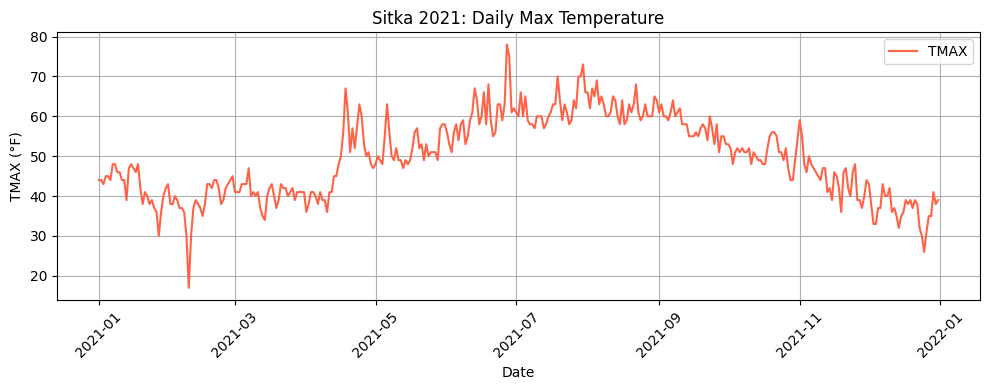

In [39]:
import matplotlib.pyplot as plt

# TMAX 컬럼 숫자 변환 (에러 시 NaN 처리)
df['TMAX'] = pd.to_numeric(df['TMAX'], errors='coerce')

# 날짜 형식으로 변환
df['DATE'] = pd.to_datetime(df['DATE'])

# 선 그래프
plt.figure(figsize=(10, 4))
plt.plot(df['DATE'], df['TMAX'], label='TMAX', color='tomato')
plt.title('Sitka 2021: Daily Max Temperature')
plt.xlabel('Date')
plt.ylabel('TMAX (°F)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()


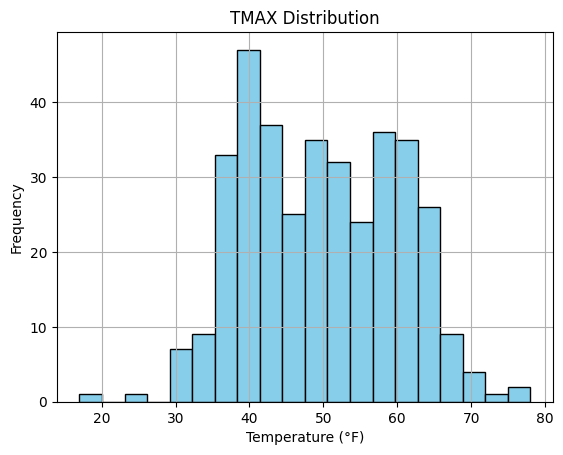

In [40]:
plt.hist(df['TMAX'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('TMAX Distribution')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [ ]:
from collections import defaultdict

defaultdict([])


C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3140\1671864688.py:35: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) 

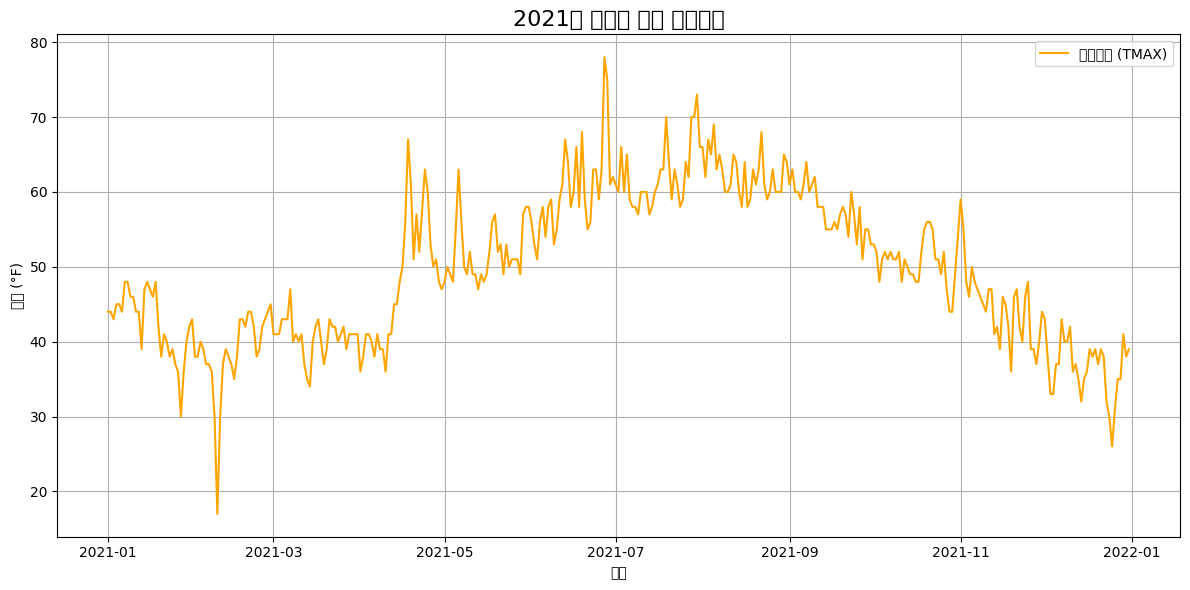

In [47]:
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import datetime

file_path = 'weather_data/sitka_weather_2021_simple.csv'

# 1. defaultdict 생성
tmax_by_date = defaultdict(list)

# 2. CSV 파일 읽기
with open(file_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            date = datetime.datetime.strptime(row['DATE'], '%Y-%m-%d')
            tmax = float(row['TMAX'])
            tmax_by_date[date].append(tmax)
        except (ValueError, KeyError):
            # 누락된 값이 있거나 파싱 실패 시 생략
            continue

# 3. defaultdict → 리스트로 변환 (정렬)
sorted_dates = sorted(tmax_by_date.keys())
tmax_values = [sum(tmax_by_date[date]) / len(tmax_by_date[date]) for date in sorted_dates]

# 4. 시각화
plt.figure(figsize=(12, 6))
plt.plot(sorted_dates, tmax_values, label='최고기온 (TMAX)', color='orange')
plt.title('2021년 날짜별 평균 최고기온', fontsize=16)
plt.xlabel('날짜')
plt.ylabel('기온 (°F)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
import datetime as dt

In [44]:
d = dt.date(2025, 7,9)
type(d)


datetime.date

In [46]:
dt.datetime.strptime('2025-07-09', '%Y-%m-%d')

datetime.datetime(2025, 7, 9, 0, 0)